In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Evaluation Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setting a clean style for our plots
sns.set_theme(style="whitegrid")

In [11]:
# Loading the dataset using the relative path as instructed
df = pd.read_csv('../data/q1_heart_disease.csv')

# Inspection
print("Dataset Shape:", df.shape)
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Displaying the first 5 rows
df.head()

Dataset Shape: (800, 12)

--- Data Types ---
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

--- Missing Values ---
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


C:\Users\Net\AppData\Local\Temp\ipykernel_16924\648139155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette='viridis')


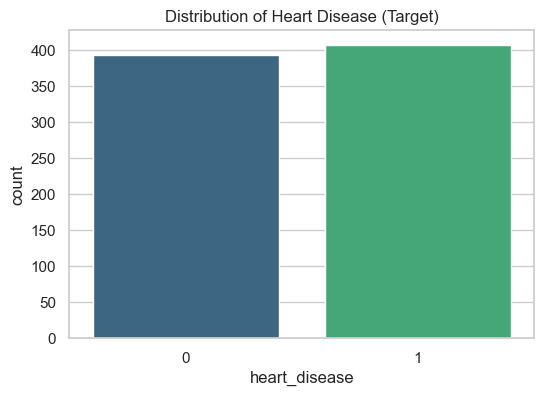

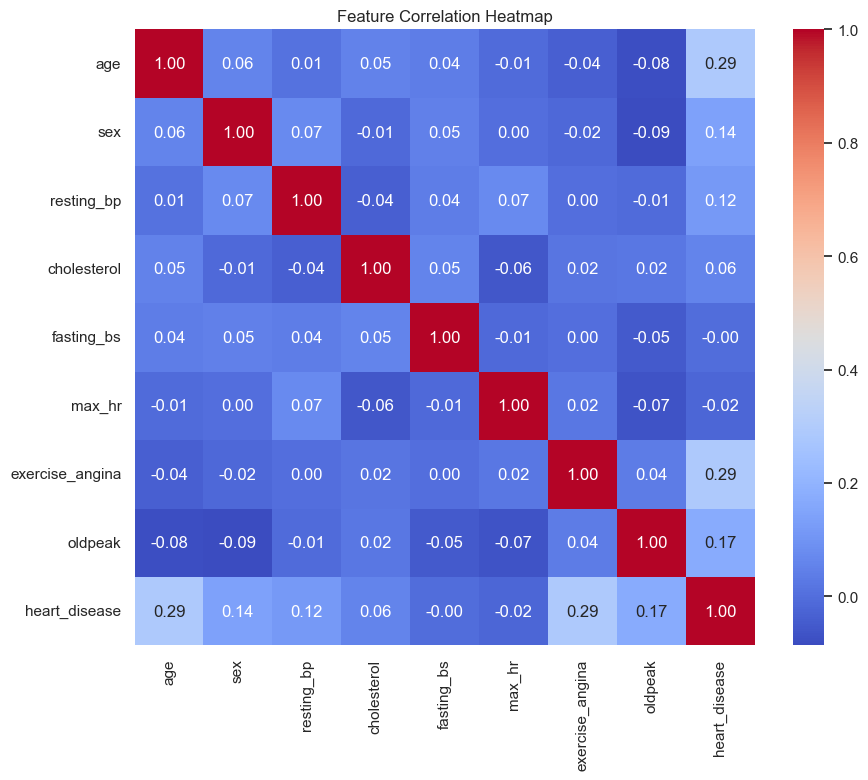

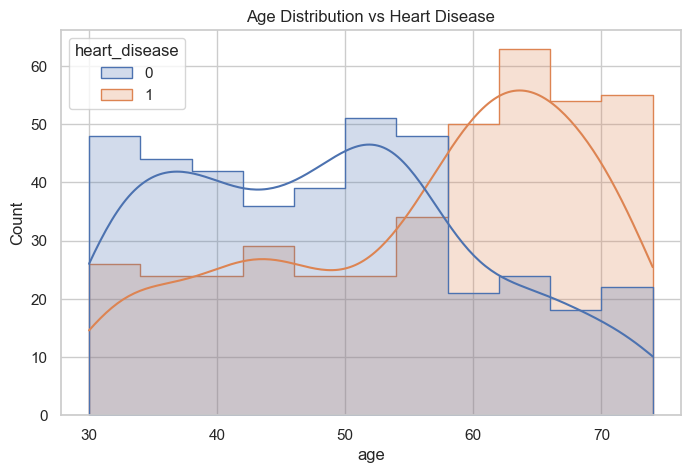

In [12]:
# 1. Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df, palette='viridis')
plt.title('Distribution of Heart Disease (Target)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Only correlate numeric columns to avoid errors
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Age distribution by Heart Disease status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, element="step")
plt.title('Age Distribution vs Heart Disease')
plt.show()

In [13]:
# Handling Missing Values
# Strategy: Dropping rows with nulls (assuming they are a small percentage of the data)
df_cleaned = df.dropna()
print(f"Rows after dropping missing values: {len(df_cleaned)}")

# Splitting Features and Target
X = df_cleaned.drop('heart_disease', axis=1)
y = df_cleaned['heart_disease']

# Identifying Categorical and Numerical columns for proper encoding/scaling
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# One-hot encoding for categorical and Scaling for numerical
# We'll use get_dummies for simplicity to keep it "human-written"
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Splitting the data (42 is the answer to everything!)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling numerical features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing complete. Training set size:", X_train.shape)

Rows after dropping missing values: 745
Preprocessing complete. Training set size: (596, 15)


C:\Users\Net\AppData\Local\Temp\ipykernel_16924\2191046414.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


In [14]:
from sklearn.linear_model import LogisticRegression

# Initializing models
# Note: LogisticRegression is one word (no space!)
log_reg = LogisticRegression(max_iter=1000)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting the models on our scaled training data
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Training Random Forest...")
rf_clf.fit(X_train, y_train)

print("Training complete.")

Training Logistic Regression...
Training Random Forest...
Training complete.


In [15]:
# Making predictions on the test set
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# Evaluation - Logistic Regression
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.2f}")
print(classification_report(y_test, y_pred_log))

# Evaluation - Random Forest
print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Performance ---
Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.77      0.79      0.78        72
           1       0.80      0.78      0.79        77

    accuracy                           0.79       149
   macro avg       0.79      0.79      0.79       149
weighted avg       0.79      0.79      0.79       149


--- Random Forest Performance ---
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        72
           1       0.81      0.83      0.82        77

    accuracy                           0.81       149
   macro avg       0.81      0.81      0.81       149
weighted avg       0.81      0.81      0.81       149

